# Project Setup

## Project Details (Add Project Name)

- **Dataset:** Home Credit Default Risk Dataset - "application_train.csv"  
- **Author:** Evan Reynolds
- **Date:** 17/07/2025
- **Objective:**   See MD File for scope
- **Status:** In Progress - Working on Section ***

## Environment and Imports

In [1]:
# ════════════════════════════════
# Environment Setup
# ════════════════════════════════

# ── Standard Library ────────────────────
import os
import sys
import warnings
import math


# ── Data ──────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib import cm, colors

# ── Machine Learning (only needed once you start modelling) ──
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display




def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent


repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

from python_style_util import f, s, p, palette, fonts, sizes, set_style, show_fonts, show_tokens, show_palette, show_style_guide, show_colormaps, C, Shade, Size
import evaluation_utils as eu
import missingno as msno        # missingness assessment functions

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Display Settings

In [2]:
# --- Pandas ---
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---
np.set_printoptions(
    precision=4,        # decimal places
    suppress=True,      # no scientific notation
    linewidth=120,      # wrap width
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---
%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---
InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---
set_style()

## Style Guide

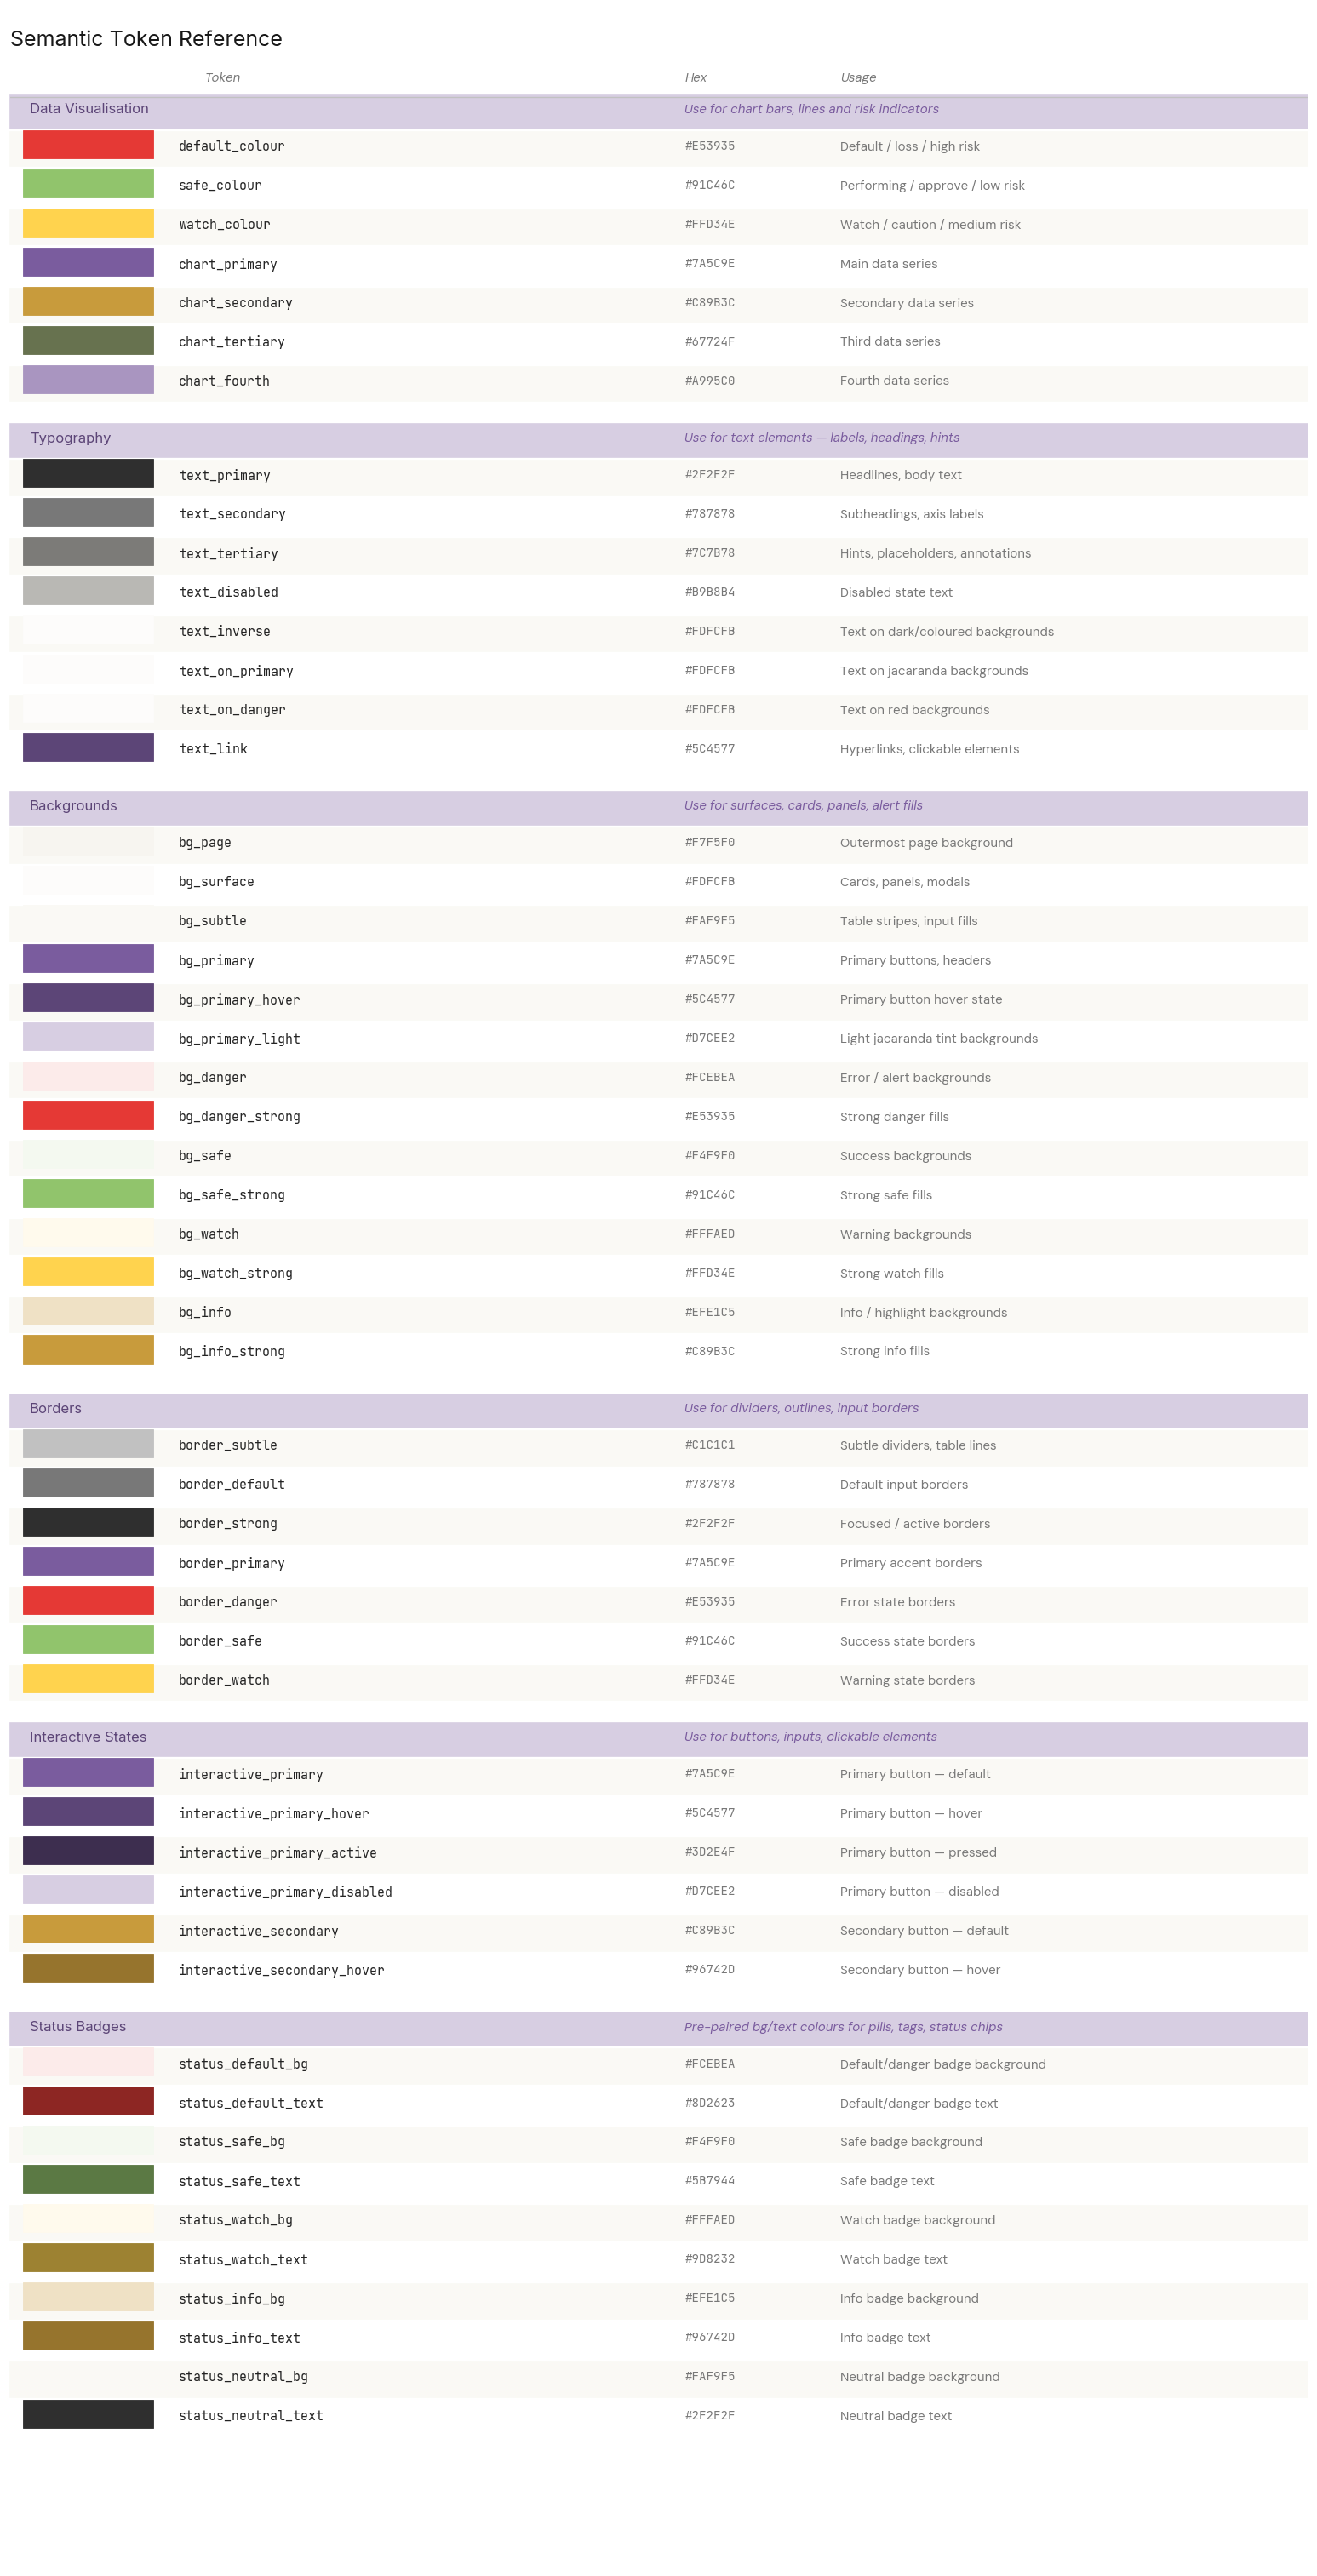

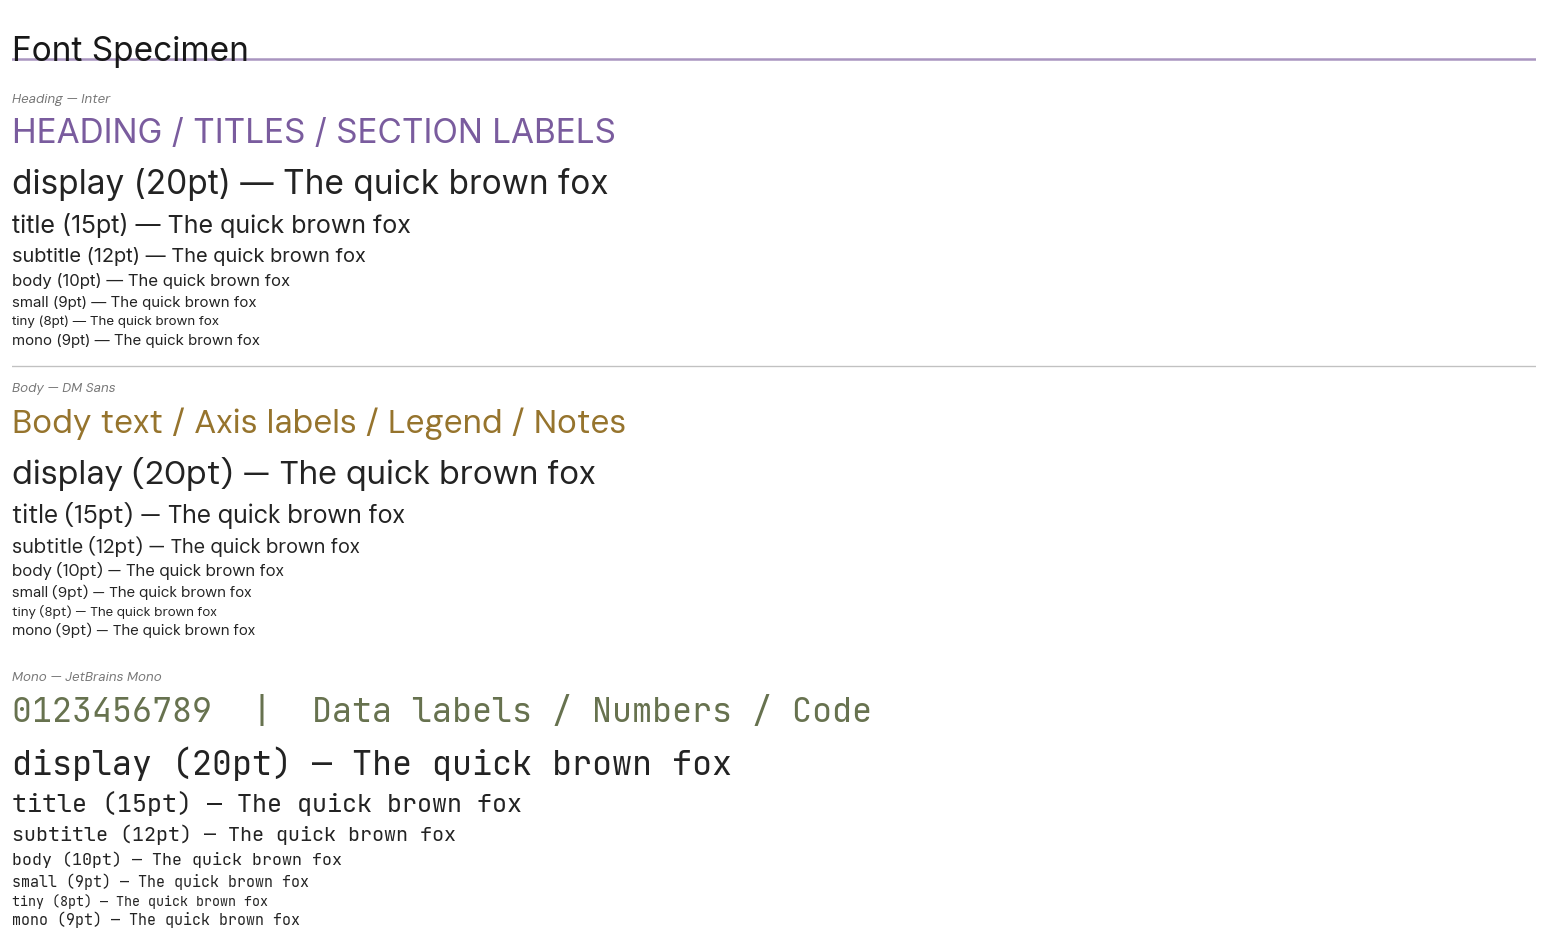

In [3]:
# Quick visual reference for the project's colour tokens and fonts
show_tokens()
show_fonts()

## Data Loading

In [4]:
# repo_root is defined in the Environment cell above.
# Point DATA_PATH at your dataset inside the Datasets folder.
DATA_PATH = os.path.join(repo_root, 'Datasets', 'Home Credit Default Risk', 'application_train.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns from {DATA_PATH}")
df.head()

desc = pd.read_csv('../../Datasets/Home Credit Default Risk/HomeCredit_columns_description.csv', sep=',', encoding='cp1252')

Loaded 307,511 rows × 122 columns from c:\Users\User\Desktop\CreditRiskLearning\Datasets\Home Credit Default Risk\application_train.csv


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

# Project Body

## 1. First Look

### Data Shape

**Prediction:** Expecting large dataset with significant breadth and volume 

In [5]:
df.shape

(307511, 122)

**Obvervation:** 300k+ Rows and 122 Columns. 

**Decision:** Will need to split into statistical categories and potentially similar buckets (i.e. applicant data, security data, social data) for further assessment as attempting look at this number of columns as a whole group will make it difficult to draw tangible conslusions.

### Class Imbalance

**Prediction:** Typically defaulters are a very small percentage of a mortgage loan book as the financial health of bank is reliant on this percentage staying low given the huge losses taken upon mortgage default.

In [6]:
df["TARGET"].value_counts(normalize=True)

TARGET
0   0.92
1   0.08
Name: proportion, dtype: float64

**Observation:** 92% Non Defaulters vs 8% Defaulters

**Decision:** Non-Defualters make up a large portion of the loan book as expected, however 8% default rate is still extremely high given industry averages (insert industry average default rate). Indicates the lender has already priced in a riskier target market through rates/fees or is in a vulnerable financial position if the default is not addressed meaningfully through either policy changes or financial controls.

In [7]:
# Filter to the application table first (Row repeats across the 7 source tables,
# so filtering before indexing avoids ambiguous/duplicate matches)
desc_app = desc[desc['Table'] == 'application_{train|test}.csv'].set_index('Row')

description_index = {}

for column in df.columns:
    if column in desc_app.index:
        description_index[column] = desc_app.loc[column, 'Description']
        
        
description_index['NAME_CONTRACT_TYPE']

'Identification if loan is cash or revolving'

## 2. Data Quality and Missingess

**Prediction:** Expecting large portion of data to be missing for various reasons, such as length of employment missing due to an applicant potentially being unemployed (MNAR). These types of missingness relationship will be established across variables by looking at cross-validation.

### 2.1 Statisitcal Subsets

Splitting data up into continuous, discrete, nominal, ordinal and binary subsets.

In [8]:
statistical_type_index = {}

nunique_counts = df.nunique()

for column in df.columns:
    
    n_unique = nunique_counts[column]
    
    dtype = df[column].dtype
    
    if n_unique == 2:
        statistical_type_index[column] = 'binary'
        
    elif n_unique > 50 and dtype in ['float64', 'int64']:
        statistical_type_index[column] = 'continuous'
    
    else:
        statistical_type_index[column] = 'needs review'
    
review_cols = [col for col, label in statistical_type_index.items() if label == 'needs review']

for col in review_cols:
    print(col, df[col].unique()[:10], description_index.get(col))
    

CODE_GENDER <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str Gender of the client
CNT_CHILDREN [0 1 2 3 4 7 5 6 8 9] Number of children the client has
NAME_TYPE_SUITE <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str Who was accompanying client when he was applying for the loan
NAME_INCOME_TYPE <StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: str Clients income type (businessman, working, maternity leave,…)
NAME_EDUCATION_TYPE <StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str Level of highest education the client achi

In [9]:
# Fix up SK_ID_CURR - add as an 'id' column

statistical_type_index.update(dict.fromkeys(['CODE_GENDER'], 'id'))

# CODE_GENDER

statistical_type_index.update(dict.fromkeys(['CODE_GENDER'], 'binary'))

# CNT_CHILDREN

statistical_type_index.update(dict.fromkeys(['CNT_CHILDREN'], 'discrete'))

# NAME_TYPE_SUITE

statistical_type_index.update(dict.fromkeys(['NAME_TYPE_SUITE'], 'categorical'))

# NAME_INCOME_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_INCOME_TYPE'], 'categorical'))

# NAME_EDUCATION_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_EDUCATION_TYPE'], 'categorical'))

# NAME_FAMILY_STATUS

statistical_type_index.update(dict.fromkeys(['NAME_FAMILY_STATUS'], 'categorical'))

# NAME_HOUSING_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_HOUSING_TYPE'], 'categorical'))

# OCCUPATION_TYPE

statistical_type_index.update(dict.fromkeys(['OCCUPATION_TYPE'], 'categorical'))

# CNT_FAM_MEMBERS

statistical_type_index.update(dict.fromkeys(['CNT_FAM_MEMBERS'], 'discrete'))

# REGION_RATING_CLIENT

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT'], 'ordinal'))

# REGION_RATING_CLIENT_W_CITY

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT_W_CITY'], 'ordinal'))

# WEEKDAY_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['WEEKDAY_APPR_PROCESS_START'], 'categorical'))

# HOUR_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['HOUR_APPR_PROCESS_START'], 'categorical'))

# ORGANIZATION_TYPE

statistical_type_index.update(dict.fromkeys(['ORGANIZATION_TYPE'], 'categorical'))

# ELEVATORS_MODE

statistical_type_index.update(dict.fromkeys(['ELEVATORS_MODE'], 'continuous'))

# ENTRANCES_MODE	

statistical_type_index.update(dict.fromkeys(['ENTRANCES_MODE'], 'continuous'))

# FLOORSMAX_MODE

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MODE'], 'continuous'))

# FLOORSMIN_MODE

statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MODE'], 'continuous'))

# ELEVATORS_MEDI	

statistical_type_index.update(dict.fromkeys(['ELEVATORS_MEDI'], 'continuous'))

# ENTRANCES_MEDI

statistical_type_index.update(dict.fromkeys(['ENTRANCES_MEDI'], 'continuous'))

# FLOORSMAX_MEDI

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MEDI'], 'continuous'))

# FLOORSMIN_MEDI

statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MEDI'], 'continuous'))

# FONDKAPREMONT_MODE

statistical_type_index.update(dict.fromkeys(['FONDKAPREMONT_MODE'], 'categorical'))

# HOUSETYPE_MODE

statistical_type_index.update(dict.fromkeys(['HOUSETYPE_MODE'], 'categorical'))

# WALLSMATERIAL_MODE

statistical_type_index.update(dict.fromkeys(['WALLSMATERIAL_MODE'], 'categorical'))

# OBS_30_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['OBS_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_30_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['DEF_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# OBS_60_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['OBS_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_60_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['DEF_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_HOUR

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_HOUR'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_DAY	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_DAY'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_WEEK

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_WEEK'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_MON

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_MON'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_QRT

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_QRT'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_YEAR

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_YEAR'], 'discrete'))


In [10]:
# Inverting statistical reference lookup so that columns can be called easier - e.g. df[cols_by_type['discrete']]

from collections import defaultdict

cols_by_type = defaultdict(list)
for col, t in statistical_type_index.items():
    cols_by_type[t].append(col)

In [11]:
# Statistical Type Dicitonary Lookup

df[cols_by_type['discrete']]

,CNT_CHILDREN,CNT_FAM_MEMBERS,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,1.00,2.00,2.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,1.00
1,0,2.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0,2.00,2.00,0.00,2.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,1.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,1.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,1.00,6.00,0.00,6.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00
307509,0,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [12]:
# Sanity check that all the columns have been assigned statistical types

assert set(df.columns) == set(statistical_type_index), \
    set(df.columns) ^ set(statistical_type_index)

valid = {'binary','discrete','continuous','categorical','ordinal', 'id'}
bad = {c: t for c, t in statistical_type_index.items() if t not in valid}
assert not bad, bad          # this would have caught 'cateogrical'

df.shape
len(statistical_type_index)

(307511, 122)

122

### 2.2 Thematic Subsets

In [13]:
# Cell Written by AI

# --- Build thematic index -------------------------------------------------
# Group all 122 columns into business themes so the target scan, block drop
# decisions, and the stakeholder narrative can work a family at a time.
# Explicit lists handle the irregular core columns; regex rules handle the
# large regular families (building stats, doc flags, bureau enquiries, ...).
# The coverage check at the end guarantees nothing is silently dropped.

import re

thematic_type_index = {}

# 1) Explicit assignments for the irregular, high-value core columns.
explicit_themes = {
    'id_target':          ['SK_ID_CURR', 'TARGET'],
    'external_scores':    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'loan_financials':    ['NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                           'AMT_ANNUITY', 'AMT_GOODS_PRICE'],
    'demographics':       ['CODE_GENDER', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
                           'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE',
                           'NAME_TYPE_SUITE'],
    'employment':         ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
                           'DAYS_EMPLOYED'],
    'assets':             ['FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY'],
    'contact':            ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                           'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'],
    'client_timeline':    ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'],
    'application_timing': ['WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START'],
}
for theme, cols in explicit_themes.items():
    for c in cols:
        if c in df.columns:
            thematic_type_index[c] = theme

# 2) Regex rules for the large regular families. Applied only to columns not
#    already claimed above; first matching rule wins.
pattern_rules = [
    ('document_flags',   r'^FLAG_DOCUMENT_\d+$'),
    ('bureau_enquiries', r'^AMT_REQ_CREDIT_BUREAU_'),
    ('social_circle',    r'_CNT_SOCIAL_CIRCLE$'),
    ('region',           r'^(REGION_|REG_|LIVE_)'),
    ('building_stats',   r'(_AVG|_MODE|_MEDI)$'),
]
for col in df.columns:
    if col in thematic_type_index:
        continue
    for theme, pattern in pattern_rules:
        if re.search(pattern, col):
            thematic_type_index[col] = theme
            break

# 3) Coverage check — print anything unassigned so it can be added above,
#    rather than letting it vanish from the scan.
unassigned = [c for c in df.columns if c not in thematic_type_index]
print(f"Assigned {len(thematic_type_index)}/{len(df.columns)} columns across "
      f"{len(set(thematic_type_index.values()))} themes")
if unassigned:
    print("\nUNASSIGNED (add to explicit_themes above):")
    for c in unassigned:
        print(f"  {c:32s} nunique={df[c].nunique():>4}  {description_index.get(c, '')}")


Assigned 122/122 columns across 14 themes


In [14]:
# Written by AI

# Invert to theme -> [columns] for block-wise access,
# e.g. df[cols_by_theme['external_scores']]  or  df[cols_by_theme['building_stats']]
from collections import defaultdict

cols_by_theme = defaultdict(list)
for col, theme in thematic_type_index.items():
    cols_by_theme[theme].append(col)

# Size overview, largest theme first
for theme in sorted(cols_by_theme, key=lambda t: -len(cols_by_theme[t])):
    members = cols_by_theme[theme]
    print(f"{theme:20s} {len(members):3d}   e.g. {members[:3]}")


building_stats        47   e.g. ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG']
document_flags        20   e.g. ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4']
region                 9   e.g. ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
demographics           8   e.g. ['CODE_GENDER', 'DAYS_BIRTH', 'CNT_CHILDREN']
contact                6   e.g. ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE']
bureau_enquiries       6   e.g. ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK']
loan_financials        5   e.g. ['NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
employment             4   e.g. ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
social_circle          4   e.g. ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']
external_scores        3   e.g. ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
assets                 3  

### 2.3 Missingness Assessment

#### Data Flagging (DAYS_EMPLOYED)

**DAYS_EMPLOYED**

The value '365243' within the DAYS_EMPLOYED column is technically a null value disguised as real entry. This value must be flagged and replaced with 'NaN' before proceeding with the missingness assesment.

**CODE_GENDER**

The value 'XNA' functions in the same way as the '365243' value in DAYS_EMPLOYED and must be handled the same way.

In [15]:
# DAYS_EMPLOYED

df['DAYS_EMPLOYED_SENTINEL'] = df['DAYS_EMPLOYED'] == 365243

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

df['DAYS_EMPLOYED'].value_counts(dropna=False)

# CODE_GENDER

df = df[df['CODE_GENDER'] != 'XNA']

df['CODE_GENDER'].value_counts(dropna=False)

C:\Users\User\AppData\Local\Temp\ipykernel_21988\1590780981.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DAYS_EMPLOYED_SENTINEL'] = df['DAYS_EMPLOYED'] == 365243


DAYS_EMPLOYED
NaN          55374
-200.00        156
-224.00        152
-199.00        151
-230.00        151
             ...  
-12316.00        1
-11100.00        1
-12971.00        1
-11084.00        1
-8694.00         1
Name: count, Length: 12574, dtype: int64

CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64

**Decision**: Flagged with a sentinel/boolean mask for the DAYS_EMPLOYED column and replaced with 'NaN'.

For the CODE_GENDER columns there were only 4 XNA values so ultimately decided to drop the rows and forgo a sentinel column.

#### Fully Populated Thematic Groups

In [16]:
# Get groups that dont have any missing data to exclude from missingness assessment

fully_populated_thematic_groups = set()

for key in cols_by_theme:
    
    missing_per_group = df[cols_by_theme[key]].isnull().sum()
    
    
    print(key + '\n')
    print(missing_per_group)
    print('\n')
    
    if (missing_per_group == 0).all():
        fully_populated_thematic_groups.add(key)    

print(fully_populated_thematic_groups)

id_target

SK_ID_CURR    0
TARGET        0
dtype: int64


external_scores

EXT_SOURCE_1    173376
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64


loan_financials

NAME_CONTRACT_TYPE      0
AMT_INCOME_TOTAL        0
AMT_CREDIT              0
AMT_ANNUITY            12
AMT_GOODS_PRICE       278
dtype: int64


demographics

CODE_GENDER               0
DAYS_BIRTH                0
CNT_CHILDREN              0
CNT_FAM_MEMBERS           2
NAME_FAMILY_STATUS        0
NAME_EDUCATION_TYPE       0
NAME_HOUSING_TYPE         0
NAME_TYPE_SUITE        1292
dtype: int64


employment

NAME_INCOME_TYPE         0
OCCUPATION_TYPE      96389
ORGANIZATION_TYPE        0
DAYS_EMPLOYED        55374
dtype: int64


assets

FLAG_OWN_CAR            0
OWN_CAR_AGE        202927
FLAG_OWN_REALTY         0
dtype: int64


contact

FLAG_MOBIL          0
FLAG_EMP_PHONE      0
FLAG_WORK_PHONE     0
FLAG_CONT_MOBILE    0
FLAG_PHONE          0
FLAG_EMAIL          0
dtype: int64


client_timeline

DAYS_REGISTRATION

#### Overall Missingness Percentage (Ranked)

Visualisation of Missingness for Columns with > 5% of data missing. Does not account for incorrect missing entries.

<Figure size 2088x2088 with 0 Axes>

Text(0.5, 1.0, 'Missingness Percentage for Columns With More than 5% of Data Missing')

Text(0.5, 0, 'Percentage Missing')

Text(0, 0.5, 'Column')

[Text(0, 0, '69.9%'),
 Text(0, 0, '69.9%'),
 Text(0, 0, '69.9%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.0%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '56.4%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '50.8%'),
 Text(0, 0, '50.8%'),
 Text(0, 0, '50.8%'),
 Text(0, 0, '50.8%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '48.8%'),
 Text(0, 0

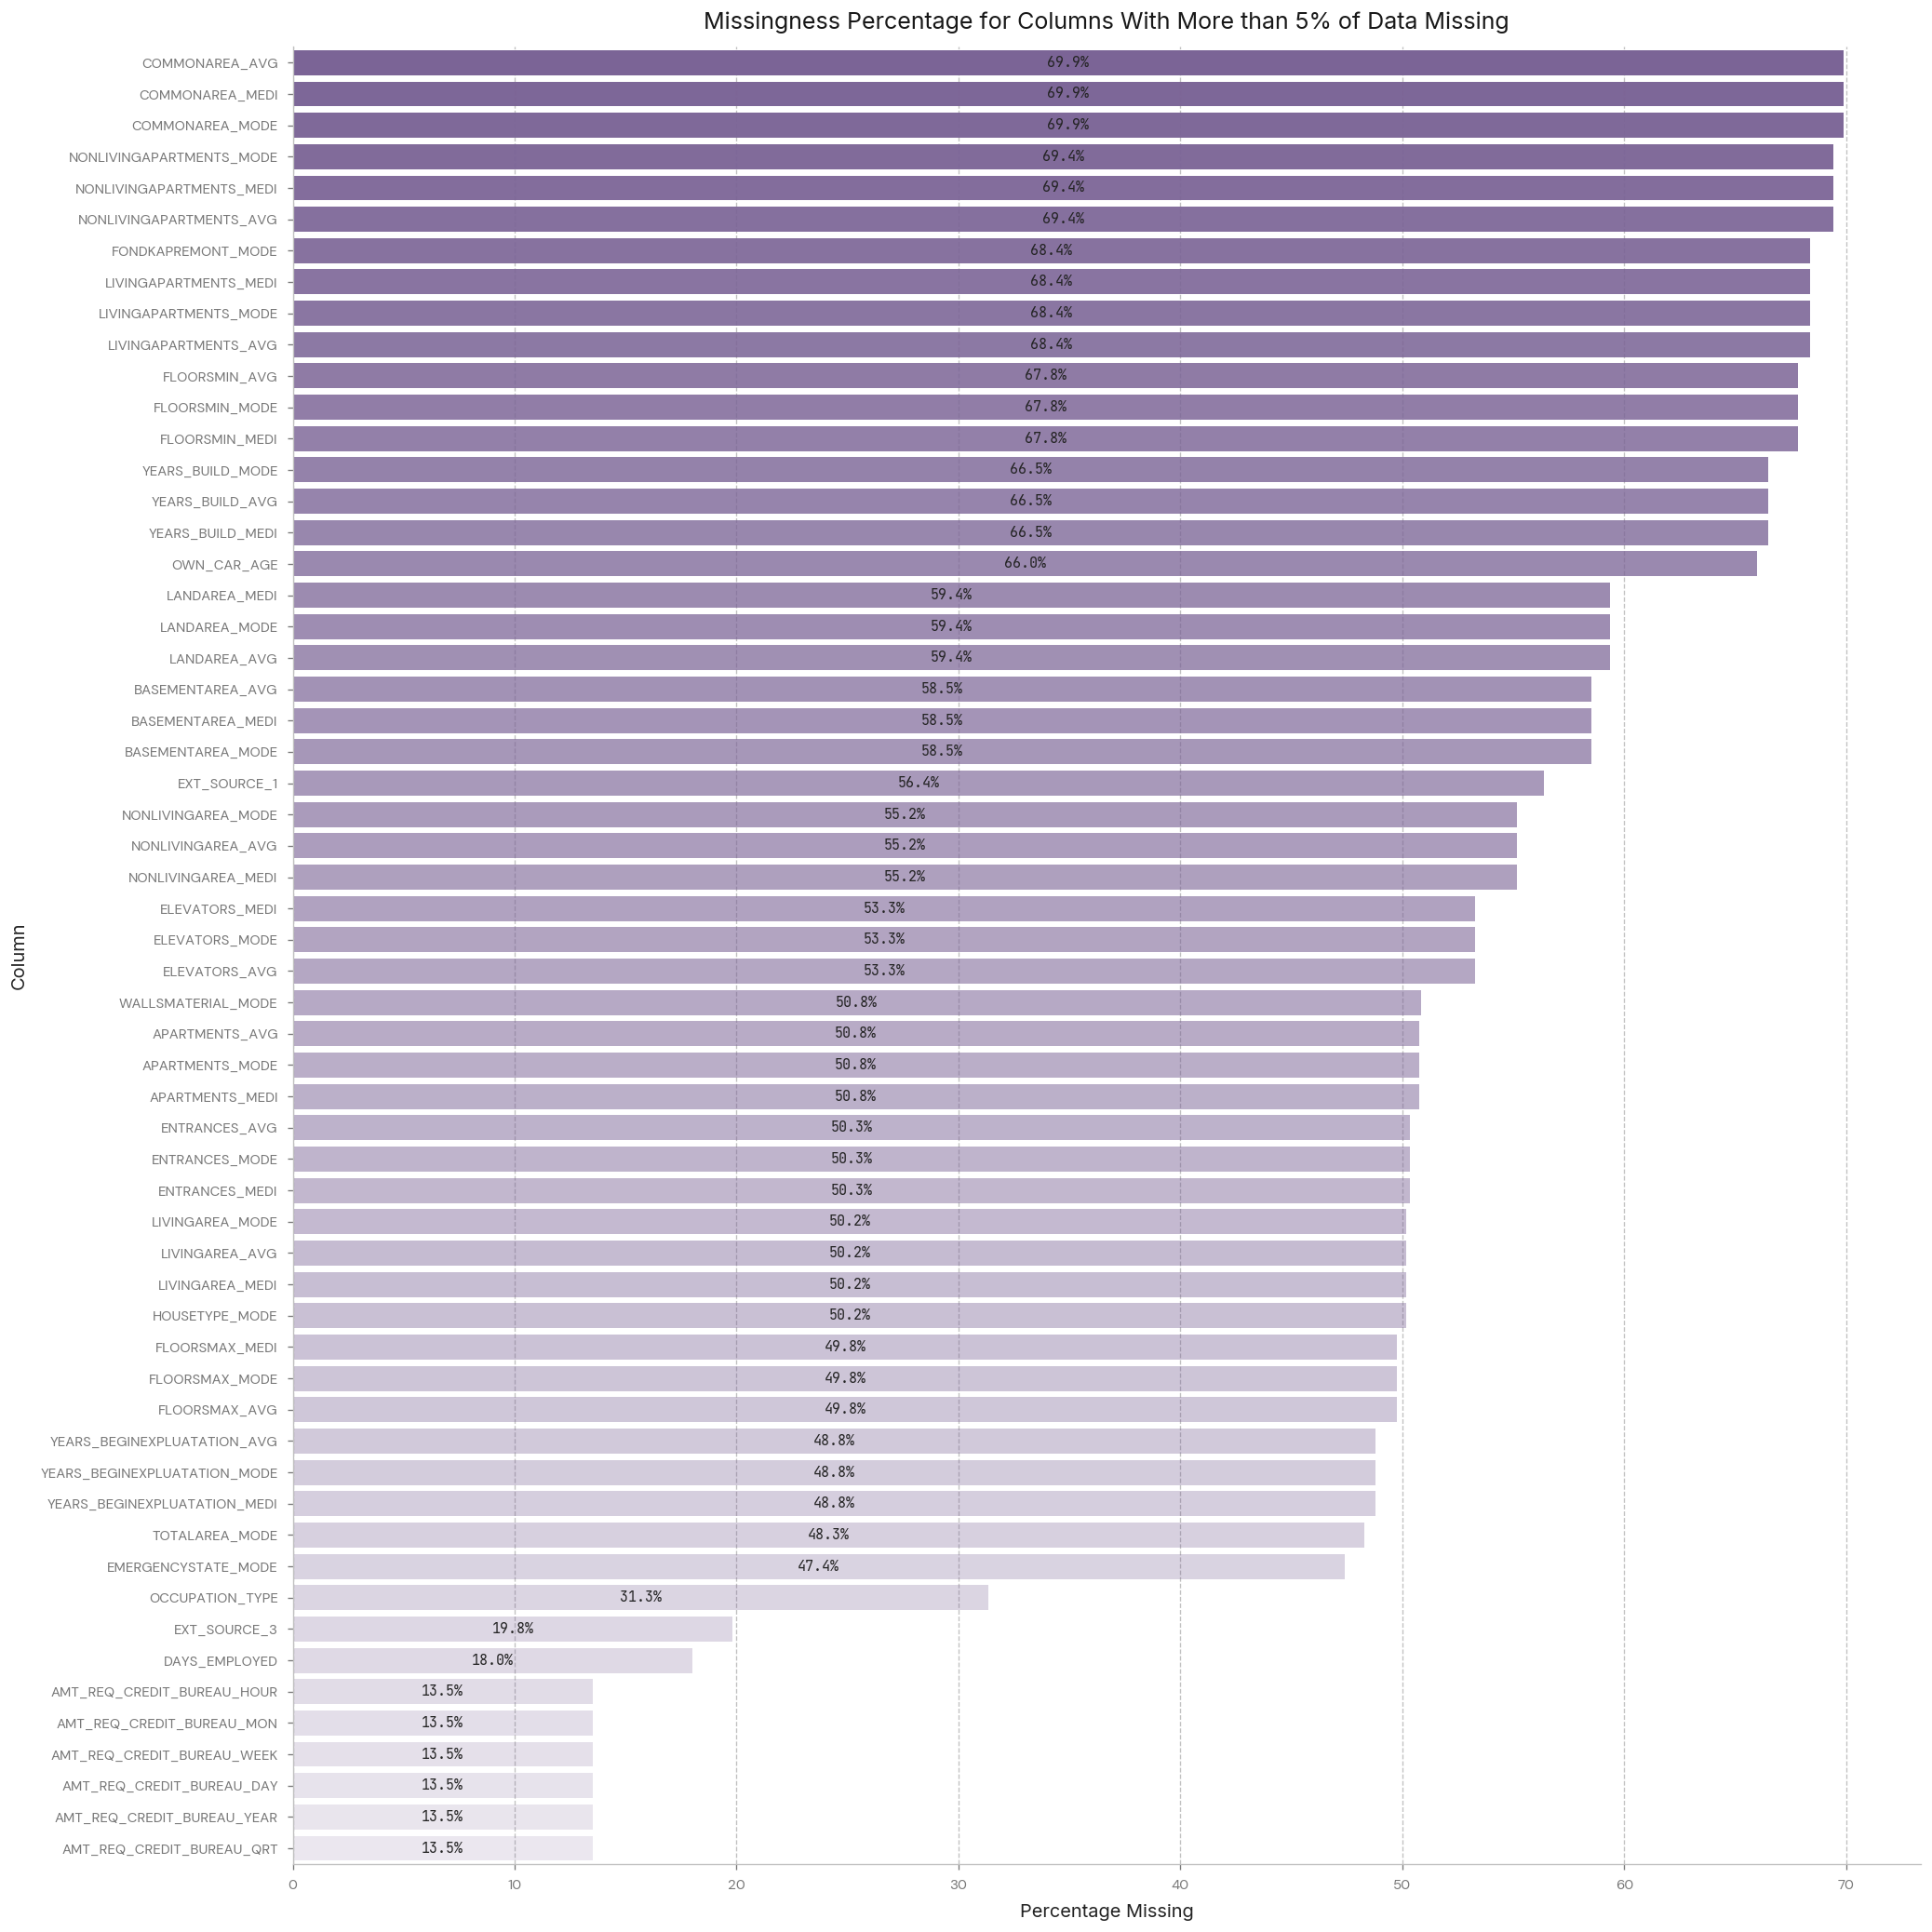

In [17]:
missingness_pct = (df.isnull().sum()/len(df) * 100).reset_index()

missingness_pct = missingness_pct.rename(columns={'index': 'column', 0 : 'pct'})

missingness_pct = missingness_pct.sort_values('pct', ascending=False)

missingness_pct = missingness_pct[missingness_pct['pct'] >= 5]

# Setting up gradient across bars
n_bars = len(missingness_pct)
alphas = np.linspace(1.0, 0.15, n_bars)

# Set Figure size with y
plt.figure(figsize=(len(missingness_pct)*0.3,len(missingness_pct)*0.3 ))

# Assigning Columns to axes and call SNS
ax = sns.barplot(missingness_pct, x='pct', y='column')

# Assigning gradient to bar chart
for bar, alpha in zip(ax.patches, alphas):
    bar.set_alpha(alpha)

# Setting chart labels and titles
ax.set_title('Missingness Percentage for Columns With More than 5% of Data Missing', fontfamily=f('heading'), fontsize= s('title'))
ax.set_xlabel("Percentage Missing", fontfamily=f('heading'), fontsize=s('subtitle'))
ax.set_ylabel("Column", fontfamily=f('heading'), fontsize=s('subtitle'))

# Setting bar labels
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=s('small'), fontfamily=f('mono'), label_type='center')

# Rendering chart
plt.tight_layout()
plt.show()


#### Missingness by Thematic Group

##### Missingness Bar Charts

Text(0.5, 1.0, 'External Scores')

Text(0.5638115555093055, 0.0, '56.4%')

Text(0.0021462926047211934, 1.0, '0.2%')

Text(0.19825564946489024, 2.0, '19.8%')

Text(0.5, 1.0, 'Loan Financials')

...

Text(0.13501806462942306, 1.0, '13.5%')

Text(0.13501806462942306, 2.0, '13.5%')

Text(0.13501806462942306, 3.0, '13.5%')

Text(0.13501806462942306, 4.0, '13.5%')

Text(0.13501806462942306, 5.0, '13.5%')

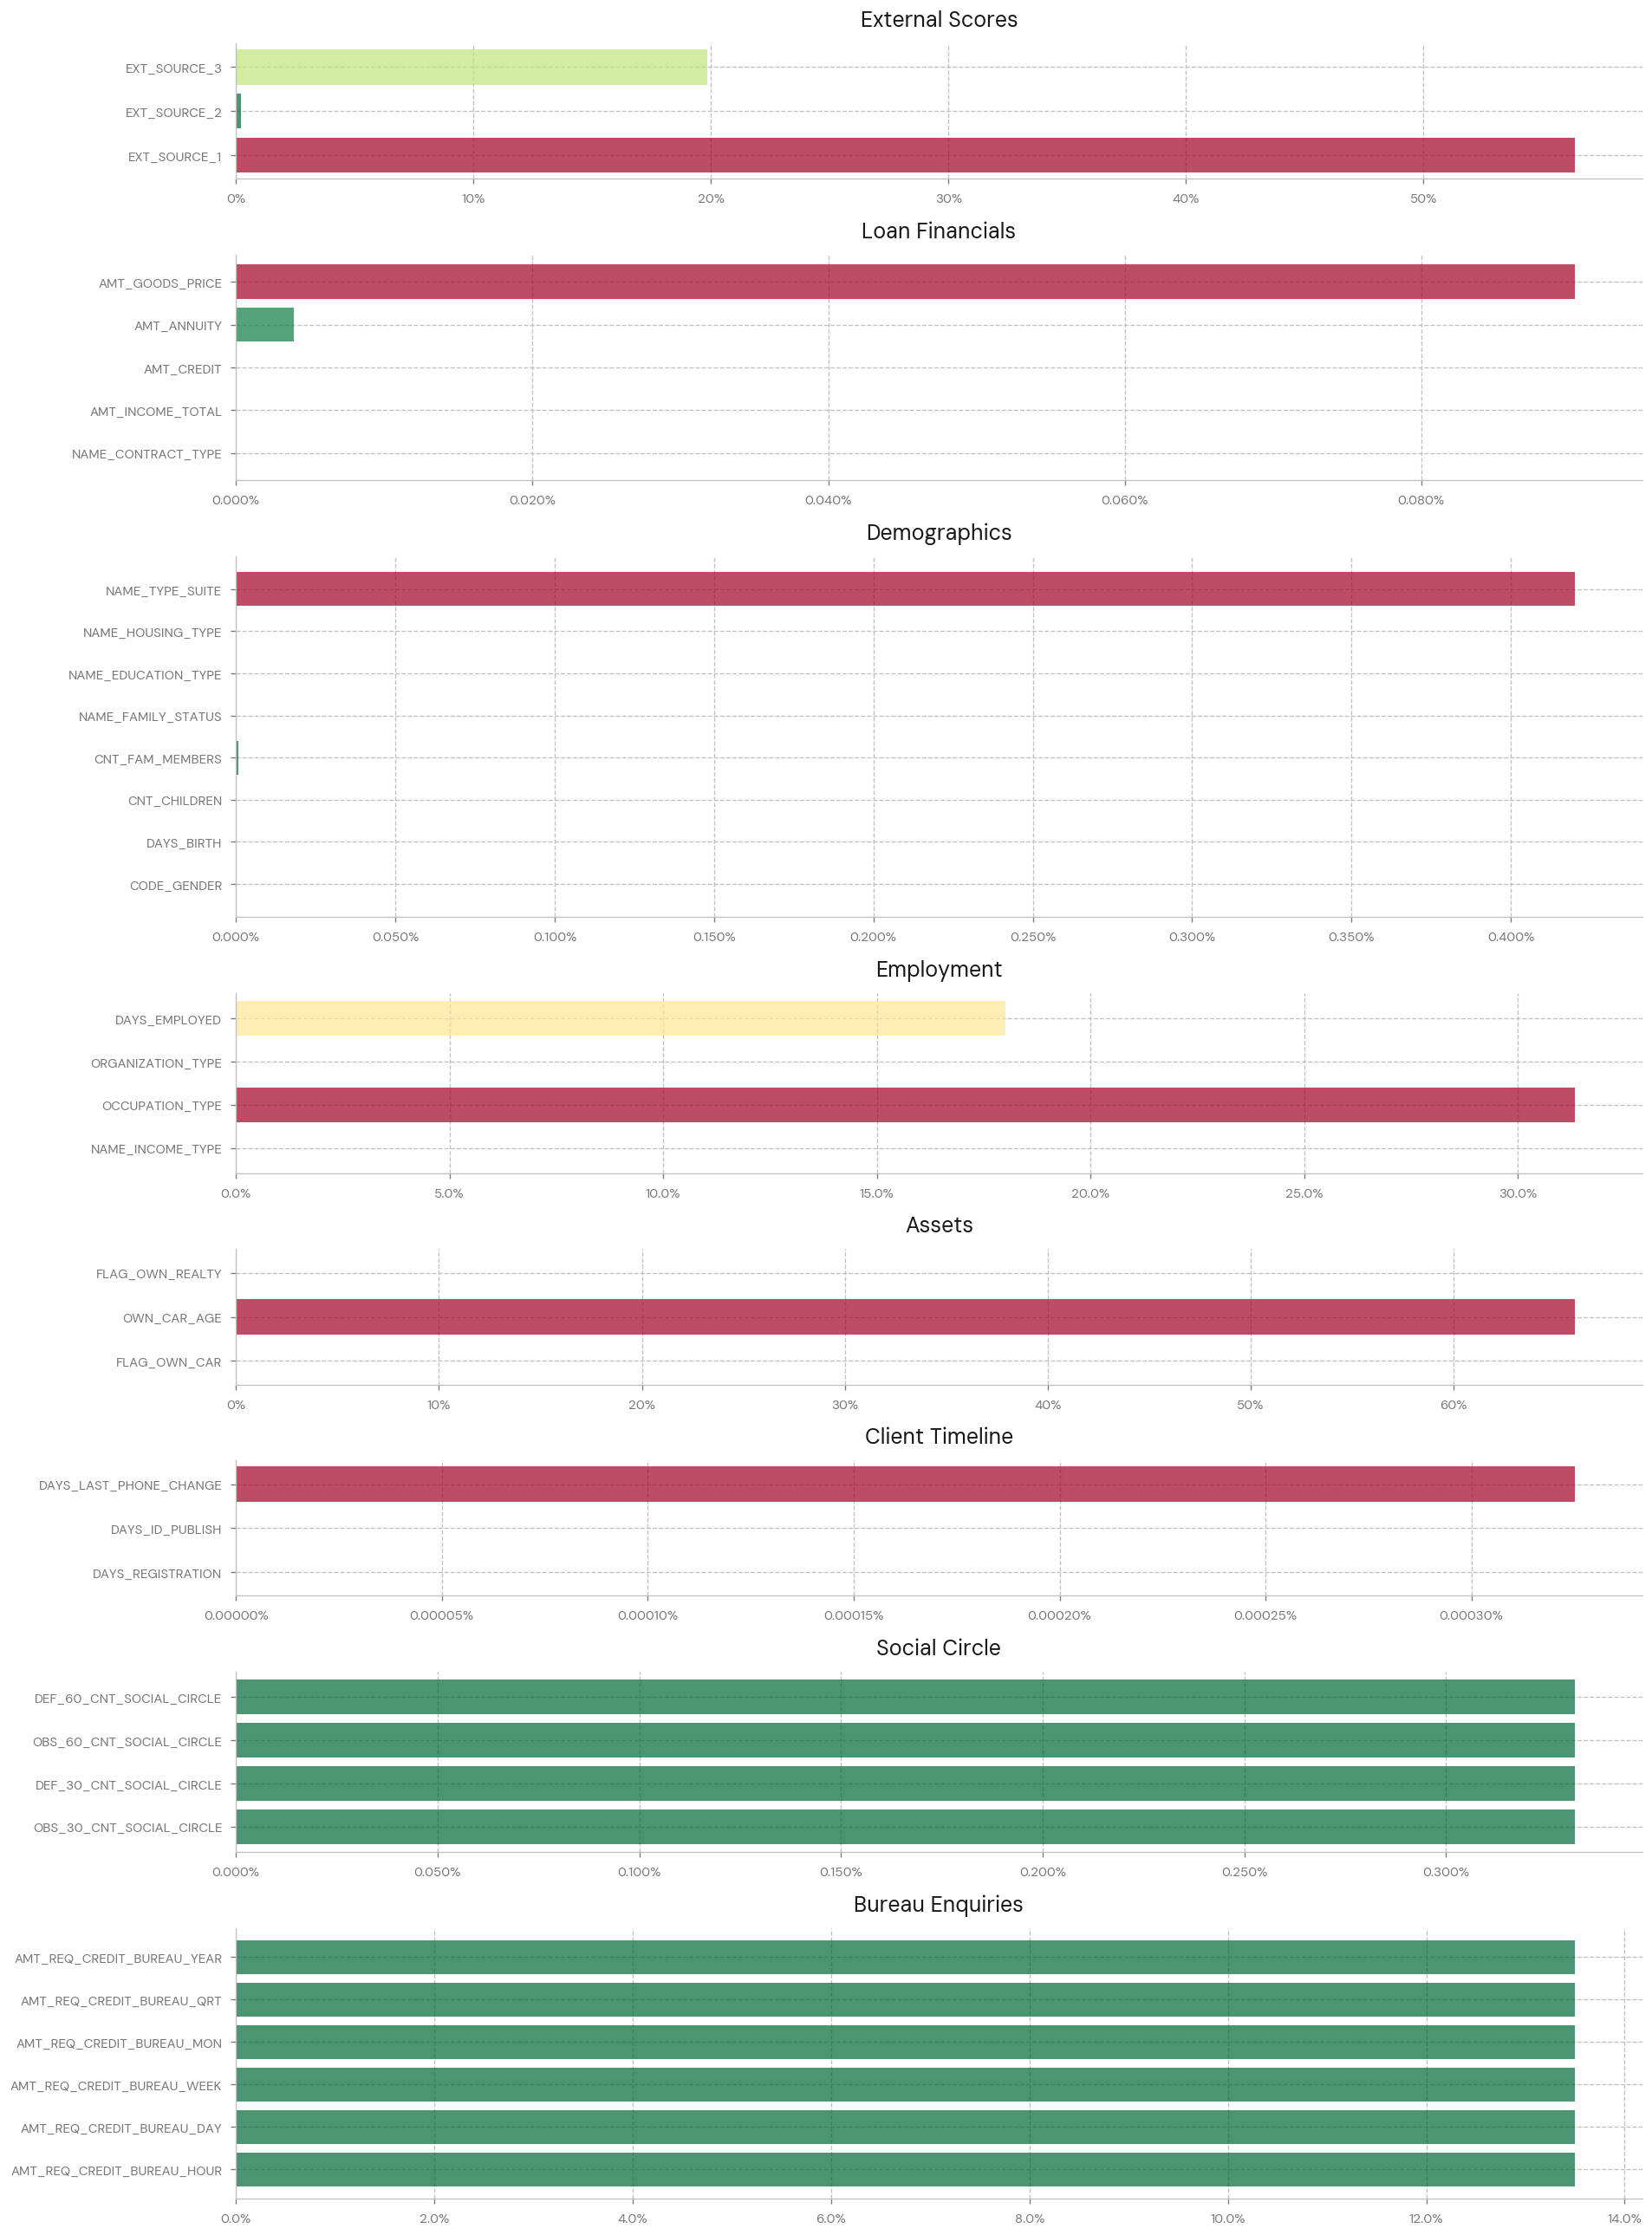

In [18]:

# Exlusion of groups with no missing values + building_stats due to size of group

exclude_thematic_groups = fully_populated_thematic_groups | {'building_stats'}

groups_to_plot = [k for k in cols_by_theme if k not in exclude_thematic_groups] 
num_figs = len(groups_to_plot)

# Setting figure count + render dimensions

bar_counts = [len(cols_by_theme[k]) for k in groups_to_plot]

n_cols = 1
n_rows = math.ceil(num_figs / n_cols)

# Setting color scheme for bar charts

cmap = cm._colormaps['RdYlGn_r']

# Setting up chart variables

n = len(df)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 0.6 * sum(bar_counts)), gridspec_kw={'height_ratios': bar_counts})
axes = axes.flatten()

# Loop to iterate through column groups for missingess percentages

for i, key in enumerate(groups_to_plot):
    
    # To drop zero values
    
    # frac = df[cols_by_theme[key]].isnull().sum() / n 
    # missing = frac[frac != 0]# missing per column
    
    # Keep zero values
    
    missing = df[cols_by_theme[key]].isnull().sum() / n 

    norm = colors.Normalize(vmin=missing.min(), vmax=missing.max())

    bars = axes[i].barh(missing.index, missing.values,
                 color=cmap(norm(missing.values)),
                 alpha = 0.7)
    axes[i].set_title(key.replace('_', ' ').title())
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    for bar in bars:
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1%}", va='center', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor='grey', alpha=0.8))
    
    
plt.tight_layout()    
plt.show()



##### Missingness Heatmap for Building Stats

In [19]:
# Missingness check across median, mode and average check null patterns

cols = cols_by_theme['building_stats']
miss = df[cols].isnull().sum()

# split each column name into (base, suffix), e.g. APARTMENTS_AVG -> ('APARTMENTS','AVG')
tbl = miss.rename_axis('col').reset_index(name='n_missing')
tbl['suffix'] = tbl['col'].str.rsplit('_', n=1).str[1]
tbl['base']   = tbl['col'].str.rsplit('_', n=1).str[0]

pivot = tbl.pivot(index='base', columns='suffix', values='n_missing')
print(pivot)


suffix                   AVG       MEDI      MODE    
base                                                 
APARTMENTS              156060.00 156060.00 156060.00
BASEMENTAREA            179942.00 179942.00 179942.00
COMMONAREA              214862.00 214862.00 214862.00
ELEVATORS               163890.00 163890.00 163890.00
EMERGENCYSTATE                NaN       NaN 145754.00
ENTRANCES               154827.00 154827.00 154827.00
FLOORSMAX               153019.00 153019.00 153019.00
FLOORSMIN               208640.00 208640.00 208640.00
FONDKAPREMONT                 NaN       NaN 210293.00
HOUSETYPE                     NaN       NaN 154296.00
LANDAREA                182588.00 182588.00 182588.00
LIVINGAPARTMENTS        210197.00 210197.00 210197.00
LIVINGAREA              154349.00 154349.00 154349.00
NONLIVINGAPARTMENTS     213512.00 213512.00 213512.00
NONLIVINGAREA           169680.00 169680.00 169680.00
TOTALAREA                     NaN       NaN 148430.00
WALLSMATERIAL               

0.6233260177847602


<Figure size 1440x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Missingness correlation across building_stats columns')

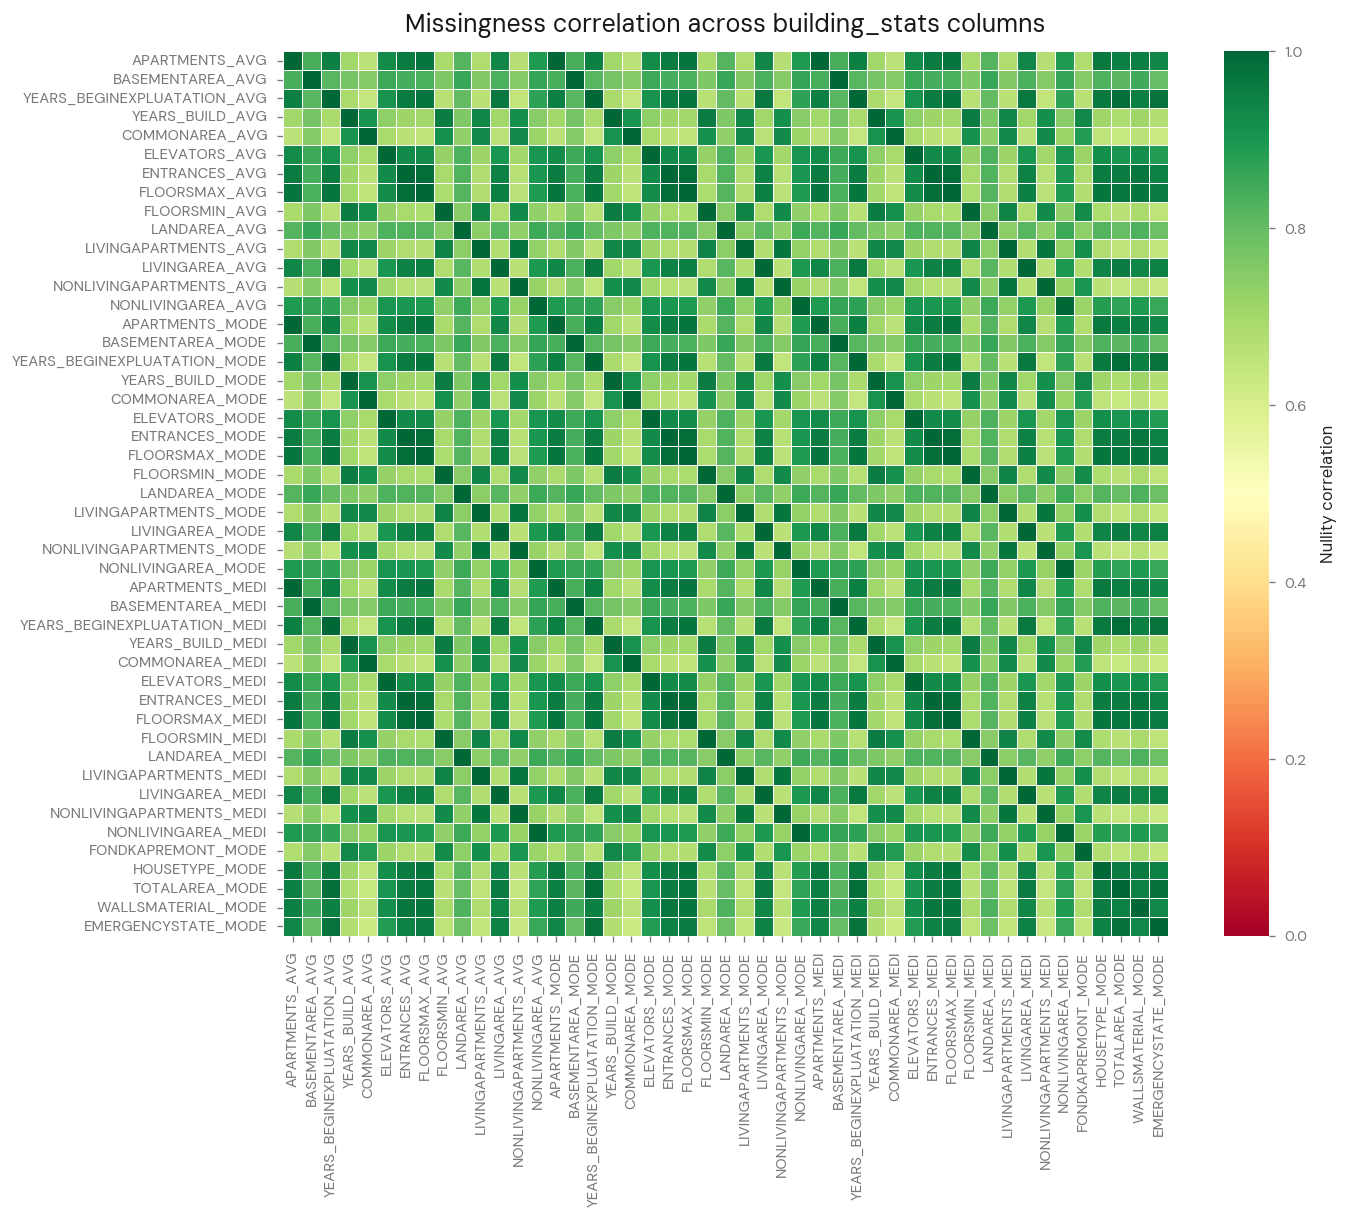

In [21]:
# Pivot Shows equivalent missingess counts across each of these columns - check correlation to confirm same values missing in each column
corr = df[cols].isnull().corr()

off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print(off_diag.min().min())

# Visualisation to confirm

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap='RdYlGn',
            vmin=0, vmax=1,      # lock scale so 1.0 = full color
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Nullity correlation'})
plt.title('Missingness correlation across building_stats columns')
plt.tight_layout()
plt.show()

# Correlation of 1 across average, median and mode for all 

**Observation**: Missingess across the average, median and mode for the building_stats thematic subgroup are equivalent

                              APARTMENTS_AVG  BASEMENTAREA_AVG  \
APARTMENTS_AVG               1.00            0.84                
BASEMENTAREA_AVG             0.84            1.00                
YEARS_BEGINEXPLUATATION_AVG  0.95            0.82                
YEARS_BUILD_AVG              0.71            0.78                
COMMONAREA_AVG               0.66            0.75                
ELEVATORS_AVG                0.92            0.85                
ENTRANCES_AVG                0.96            0.84                
FLOORSMAX_AVG                0.97            0.84                
FLOORSMIN_AVG                0.69            0.76                
LANDAREA_AVG                 0.82            0.86                
LIVINGAPARTMENTS_AVG         0.68            0.76                
LIVINGAREA_AVG               0.93            0.83                
NONLIVINGAPARTMENTS_AVG      0.67            0.75                
NONLIVINGAREA_AVG            0.89            0.87                
APARTMENTS

<BarContainer object of 14 artists>

Text(0.5, 1.0, 'Percentage of Missing Data for the Building Stats Thematic Subgroup')

Text(0, 0.5, 'Building Stat')

Text(0.5, 0, 'Percentage of Data Missing')

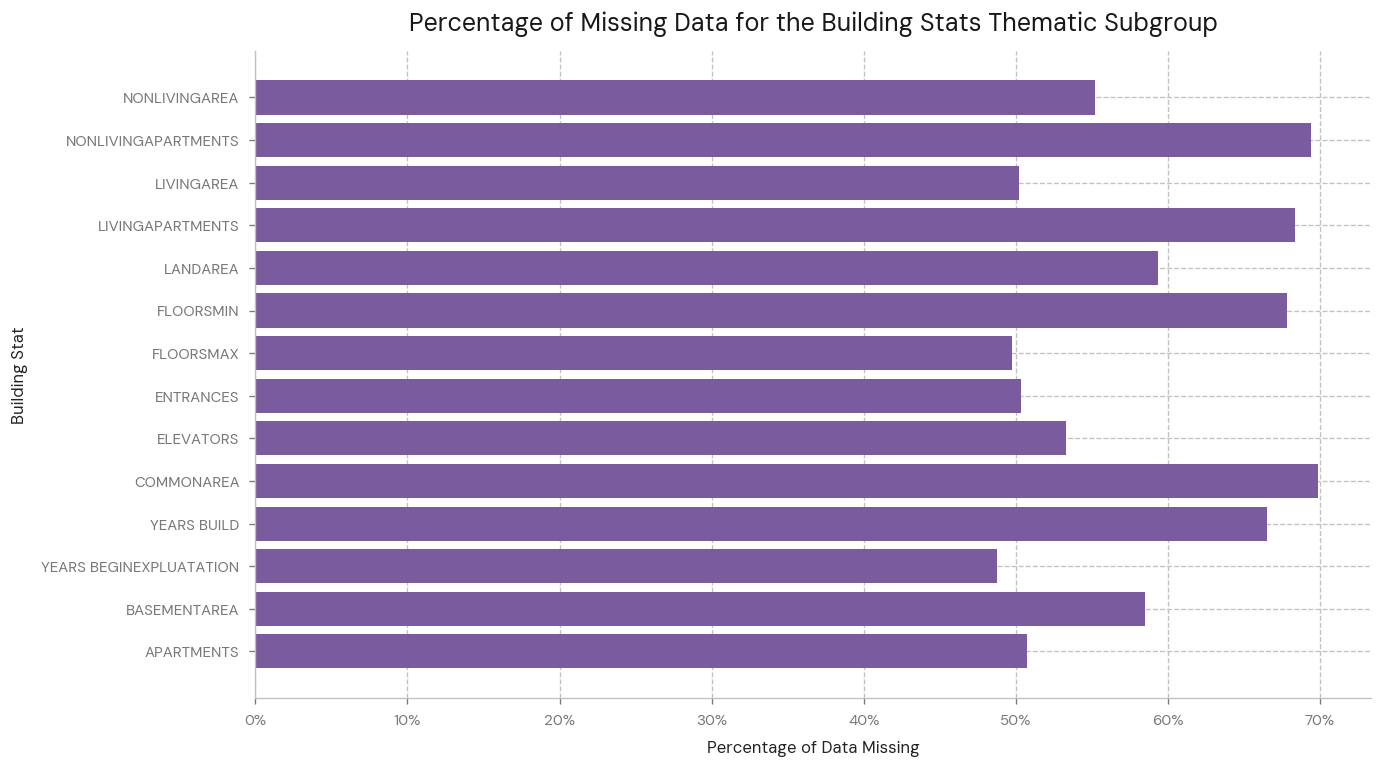

In [40]:
# Using MSNO library - basic heatmap

# Excluding median and mode columns and only using average as the missingness is shared between them 

avg_cols = [c for c in cols_by_theme['building_stats'] if 'AVG' in c]

missingness_avg_build = df[avg_cols].isnull().sum()

missingness_avg_build_cols_percentage = missingness_avg_build / n

labels = [c.replace('_AVG', '').replace('_',' ') for c in missingness_avg_build_cols_percentage.index]

print(corr)

print(missingness_avg_build_cols_percentage)

fig, ax = plt.subplots(figsize = (12, 0.5 * len(missingness_avg_build_cols_percentage)))

ax.barh(labels, missingness_avg_build_cols_percentage.values)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Percentage of Missing Data for the Building Stats Thematic Subgroup')
ax.set_ylabel('Building Stat')
ax.set_xlabel('Percentage of Data Missing')



## 3. Univariate EDA

## 4. Target Relationship Scan

## 5. WOE/IV Computation

## 6. Findings Summary

## 7. Next Steps